# Final Assignment Tutorial — Telecom

This notebook is a reference walkthrough for the GCI World 2026 Spring final assignment.
The dataset comes from **Company A**, an anonymous telecommunications service provider, and contains historical customer information across two linked tables (`Client.csv`, `Record.csv`).

Your task is to analyze this data, build a machine learning model whose output supports a concrete business proposal — not to build the best possible model.

**What this notebook walks through:**

1. Market context.
2. Loading and merging the two source tables.
3. EDA: shape, missingness, target distribution, and a worked feature example.
4. Problem Definition — choosing the target and the ML task.
5. Preprocessing — what EDA told us we have to do.
6. A baseline churn classifier.
7. Model evaluation and feature importance.
8. From model to business proposal.

> **Treat this as a reference, not a template.** The strongest submissions diverge from it: a different target, a different segment, a different lever. Originality is rewarded.


---

## 1.Introduction & Market Analysis


### 1.1 Company context

_Company A_ is a wireless telecommunications operator. They have years of usage and billing data on roughly 100,000 customers but no in-house machine learning capability.

When a company commissions a business proposal, they usually arrive with a vague sense that _something_ needs to improve — margins, retention, growth, customer satisfaction — but no clear view of which lever to pull, which segment to focus on, or even which question to start with. **Choosing the question is the analyst's first job, and the rest of the proposal stands or falls on it.** The dataset rarely points to a single obvious answer; it admits several, and which one you pursue determines the kind of recommendation you can make.

This dataset includes a binary `churn` flag — whether a customer left within 31–60 days after the observation date — and we use churn as the worked example throughout this notebook. But churn is one of many viable targets the data supports. **You may and should explore other targets** — revenue, usage, equipment lifecycle, segment-level behaviour. Pick the question whose answer best supports the proposal you want to make.


### 1.2 Why this market matters

- Acquiring a new subscriber costs several times more than keeping one — retention, usage, and ARPU all translate directly into margin.
- Mature, saturated markets grow by taking customers from competitors or lifting revenue per existing customer.
- Behaviour signals (usage decline, complaints, equipment ageing) precede both churn and revenue compression by months.

**Questions to think about:**

- What does the telecom market look like in your country or region — who are the major players, what local dynamics (regulation, technology shifts, new entrants) are reshaping churn, and what story can you tell about a specific market you know? A proposal grounded in a local market you can describe concretely is more compelling than one assembled from generic global figures.
- What recent, citable sources can you find that quantify these claims for your target market? Uncited industry numbers will not strengthen your case.
- What share of churn in this market is voluntary (customer-initiated) versus involuntary (non-payment, address change)? Which one can a model meaningfully address?


---

## 2.Setup and Data Loading


### 2.1 Import libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from xgboost import XGBClassifier, plot_importance

pd.set_option("display.max_columns", 120)


### 2.3 Load the two source tables

The dataset is split across two files:

| File         | Granularity          | Contents                                                                       |
| ------------ | -------------------- | ------------------------------------------------------------------------------ |
| `Client.csv` | one row per customer | account-level info: tenure, plan, demographics, equipment                      |
| `Record.csv` | one row per customer | mean monthly usage, billing, and call-quality metrics, plus the `churn` target |

Both tables share a `Customer_ID` column, which we use to join them into a single analysis table.


In [2]:
import os
from pathlib import Path

current_dir = Path(os.getcwd())
client_path = current_dir / "telecom" / "Client.csv"
record_path = current_dir / "telecom" / "Record.csv"

for p in (client_path, record_path):
    print(f"{'OK ' if p.exists() else 'MISSING '} {p}")

OK  /home/farout101/Documents/GitHub/GCI World/final_assignment/Final Assignment/telecom/Client.csv
OK  /home/farout101/Documents/GitHub/GCI World/final_assignment/Final Assignment/telecom/Record.csv


In [4]:
client = pd.read_csv(client_path)
record = pd.read_csv(record_path)

print(f"Client: {client.shape}")
print(f"Record: {record.shape}")

Client: (100000, 50)
Record: (100000, 51)


In [5]:
# Merge on Customer_ID. Both tables have one row per customer, so this is a 1:1 join.
df = record.merge(client, on='Customer_ID', how='inner')
print(f"Merged: {df.shape}")
df.head()

Merged: (100000, 100)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,T,CHICAGO AREA,N,N,29.98999,1.0,1.0,NaN,0.0,0.0,NaN,6.0,M,M,4.0,M,6.0,1.0,C,D,0.0,U,Y,U,U,U,U,Y,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,U,NEW ENGLAND AREA,Y,N,149.98999,6.0,4.0,WCMB,0.0,0.0,R,5.0,M,S,1.0,M,6.0,1.0,C,O,0.0,I,U,U,U,U,U,Y,434.0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 100 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   rev_Mean          99643 non-null   float64
 1   mou_Mean          99643 non-null   float64
 2   totmrc_Mean       99643 non-null   float64
 3   da_Mean           99643 non-null   float64
 4   ovrmou_Mean       99643 non-null   float64
 5   ovrrev_Mean       99643 non-null   float64
 6   vceovr_Mean       99643 non-null   float64
 7   datovr_Mean       99643 non-null   float64
 8   roam_Mean         99643 non-null   float64
 9   change_mou        99109 non-null   float64
 10  change_rev        99109 non-null   float64
 11  drop_vce_Mean     100000 non-null  float64
 12  drop_dat_Mean     100000 non-null  float64
 13  blck_vce_Mean     100000 non-null  float64
 14  blck_dat_Mean     100000 non-null  float64
 15  unan_vce_Mean     100000 non-null  float64
 16  unan_dat_Mean     100000 non-nu

## Quick Note

- `numbcars` has only 50,634 non-null rows (nearly 50% missing!).
- `ownrent` (66,294), dwlltype (68,091), and income (74,564) are also highly incomplete.
- Columns 53–55 (new_cell, crclscod, asl_flag) and columns 93–98 (kid0_2, creditcd, etc.) are strings.

### Goldmine features of the current churn model

- `change_mou` & `change_rev` - The ultimate alarm bells. Measures if a user's talk time or spending is dropping compared to their history.
- `custcare_Mean` - High values mean they are frustrated and calling support; 0 values might mean "silent churn" where they've given up.
- `rev_Mean` vs `totmrc_Mean` - Comparing actual spending to their base contract rate tells you if they are racking up overage fees (which makes people leave!).
- `eqpdays` - Number of days they've had their current phone. If this number is very high, their device is aging, making them prime targets for a competitor offering a free upgrade.
- `blck_vce_Mean` & `drop_vce_Mean` - Direct indicators of dropped calls and network frustration.


---

## 3.Exploratory Data Analysis

Before modeling, three questions need answers:

1. **How big and structured is the data?** Rows, columns, dtypes.
2. **Where is the data incomplete or unreliable?**
3. **What does the target variable look like?**

Each answer constrains the next step. The shape and types tell us what preprocessing is required. The missingness tells us which columns may need to be dropped, imputed, or treated specially. The target distribution tells us which metrics will be meaningful.

EDA is also where the proposal starts to take shape — the patterns you see now become candidate signals for the model and anchors for the story your proposal will tell. The visualizations in this tutorial are intentionally minimal — just enough to make a point; for your proposal slides, you will want to polish them.


### 3.1 Shape and types

`df.info(verbose=False)` reports total rows, total columns, the count of columns of each dtype, and memory use. Two things to read from the output:

- **Dataset size.** Small enough to keep in pandas — no chunking needed.
- **Dtype mix.** Some columns may be stored as `object` (text). Most machine learning models can only learn from numbers, so any text columns will need to be converted to numeric form before modeling.


In [7]:
df.info(verbose=False)

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 100 entries, rev_Mean to eqpdays
dtypes: float64(69), int64(10), str(21)
memory usage: 76.3 MB


### 3.2 Missing values

A column that is mostly missing carries little signal — dropping it is often cleaner than trying to impute. We count the missing values in each column, take the 20 worst, and plot them.


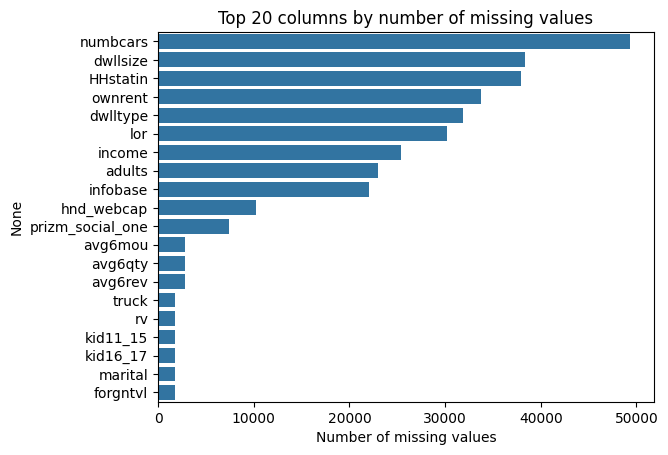

In [11]:
# Count of missing values per column
missing_counts = df.isna().sum()

# Take the 20 columns with the most missing values
top_missing = missing_counts.sort_values(ascending=False).head(20)

# Plot
sns.barplot(x=top_missing.values, y=top_missing.index)
plt.xlabel('Number of missing values')
plt.title('Top 20 columns by number of missing values')
plt.show()

### 3.3 Target variable: churn

We'll use `churn` as the worked example. Before modeling we need its class balance — whether stayers and churners appear in roughly equal numbers, or whether one class dominates. The balance directly affects which evaluation metric will be meaningful: accuracy is informative only when classes are balanced; with 5% churn it would be misleading.


churn
0    50438
1    49562
Name: count, dtype: int64

churn
0    0.50438
1    0.49562
Name: proportion, dtype: float64


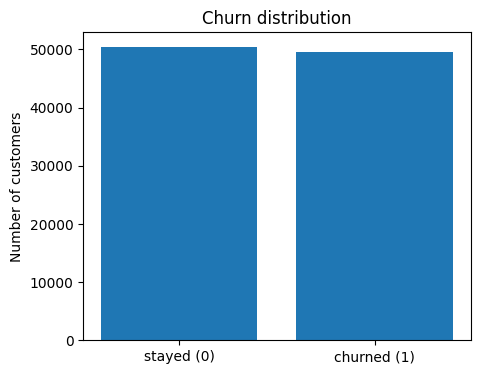

In [13]:
# Counts and proportions
print(df['churn'].value_counts())
print()
print(df['churn'].value_counts(normalize=True))

# Bar chart
counts = df['churn'].value_counts().sort_index()
labels = ['stayed (0)', 'churned (1)']

plt.figure(figsize=(5, 4))
plt.bar(labels, counts.values) #type: ignore
plt.title('Churn distribution')
plt.ylabel('Number of customers')
plt.show()

Churn is near 50% — unusually balanced for telecom (real-world datasets are typically 5–10% churn). For this dataset, accuracy will be a meaningful metric, and a model that always predicts one class will score around 0.5. If you choose a different target, redo this balance check before picking your evaluation metric.


### 3.4 A closer look: equipment age vs churn

The three checks above are dataset-wide. The real EDA work is digging into individual features — how each one relates to the target, where the differences are, and which patterns are worth following up on.

As one example: `eqpdays` records the age (in days) of each customer's current handset. Old equipment plausibly drives churn — a frustrating or outdated device makes the next contract renewal less attractive. We can check this by comparing the equipment-age distribution for churners against stayers.


Mean equipment age (stayed):  363.3 days
Mean equipment age (churned): 421.1 days


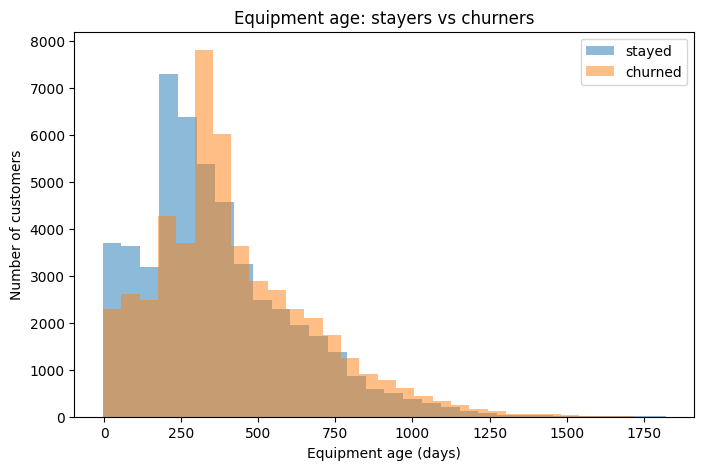

In [14]:
# Split eqpdays into two groups based on churn
stayed = df[df['churn'] == 0]['eqpdays']
churned = df[df['churn'] == 1]['eqpdays']

# Compare the averages
print(f'Mean equipment age (stayed):  {stayed.mean():.1f} days')
print(f'Mean equipment age (churned): {churned.mean():.1f} days')

# Overlay the two distributions
plt.figure(figsize=(8, 5))
plt.hist(stayed, bins=30, alpha=0.5, label='stayed')
plt.hist(churned, bins=30, alpha=0.5, label='churned')
plt.xlabel('Equipment age (days)')
plt.ylabel('Number of customers')
plt.title('Equipment age: stayers vs churners')
plt.legend()
plt.show()

Churners skew toward older equipment — the mean and the right tail of the distribution are both higher than for stayers. That makes `eqpdays` a candidate feature for both the model and the narrative your proposal will tell ("customers with ageing handsets are at higher risk; replacing or upgrading equipment is a lever").

The point is the **exercise**: pick a candidate feature, compare it across churn classes, and decide whether it is worth following up on. Repeat this on a handful of features that look promising from the dataset overview or your domain knowledge.


**Questions to think about:**

- The example above looked at one feature (`eqpdays`). Pick three or four other candidates — from the dataset overview, from Section 1.2, or from your own intuition — and run the same comparison.
- ~100 columns is a lot. Which look like near-duplicates of each other (e.g., several variations on revenue or minutes)?
- Are any columns _too good to be true_ — could they leak the target?
- How does the target distribute across segments (geographic, plan, demographic, credit class)? Which segments behave differently and might deserve separate analysis?
- Are there outliers or implausible values you should clean before modeling?


### 3.5 Pairwise view: revenue, usage, equipment age, and churn

The previous plot looked at one feature at a time.  
Here we compare several business-relevant numeric features together:

- `rev_Mean`: average monthly revenue
- `mou_Mean`: average monthly minutes of use
- `totmrc_Mean`: average monthly recurring charge
- `eqpdays`: equipment age in days
- `months`: customer tenure

A pairplot helps us see whether churned customers occupy different regions in the joint feature space.


/home/farout101/Documents/GitHub/GCI World/competition-20260525T102043Z-3-001/competition/venv/lib64/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/farout101/Documents/GitHub/GCI World/competition-20260525T102043Z-3-001/competition/venv/lib64/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


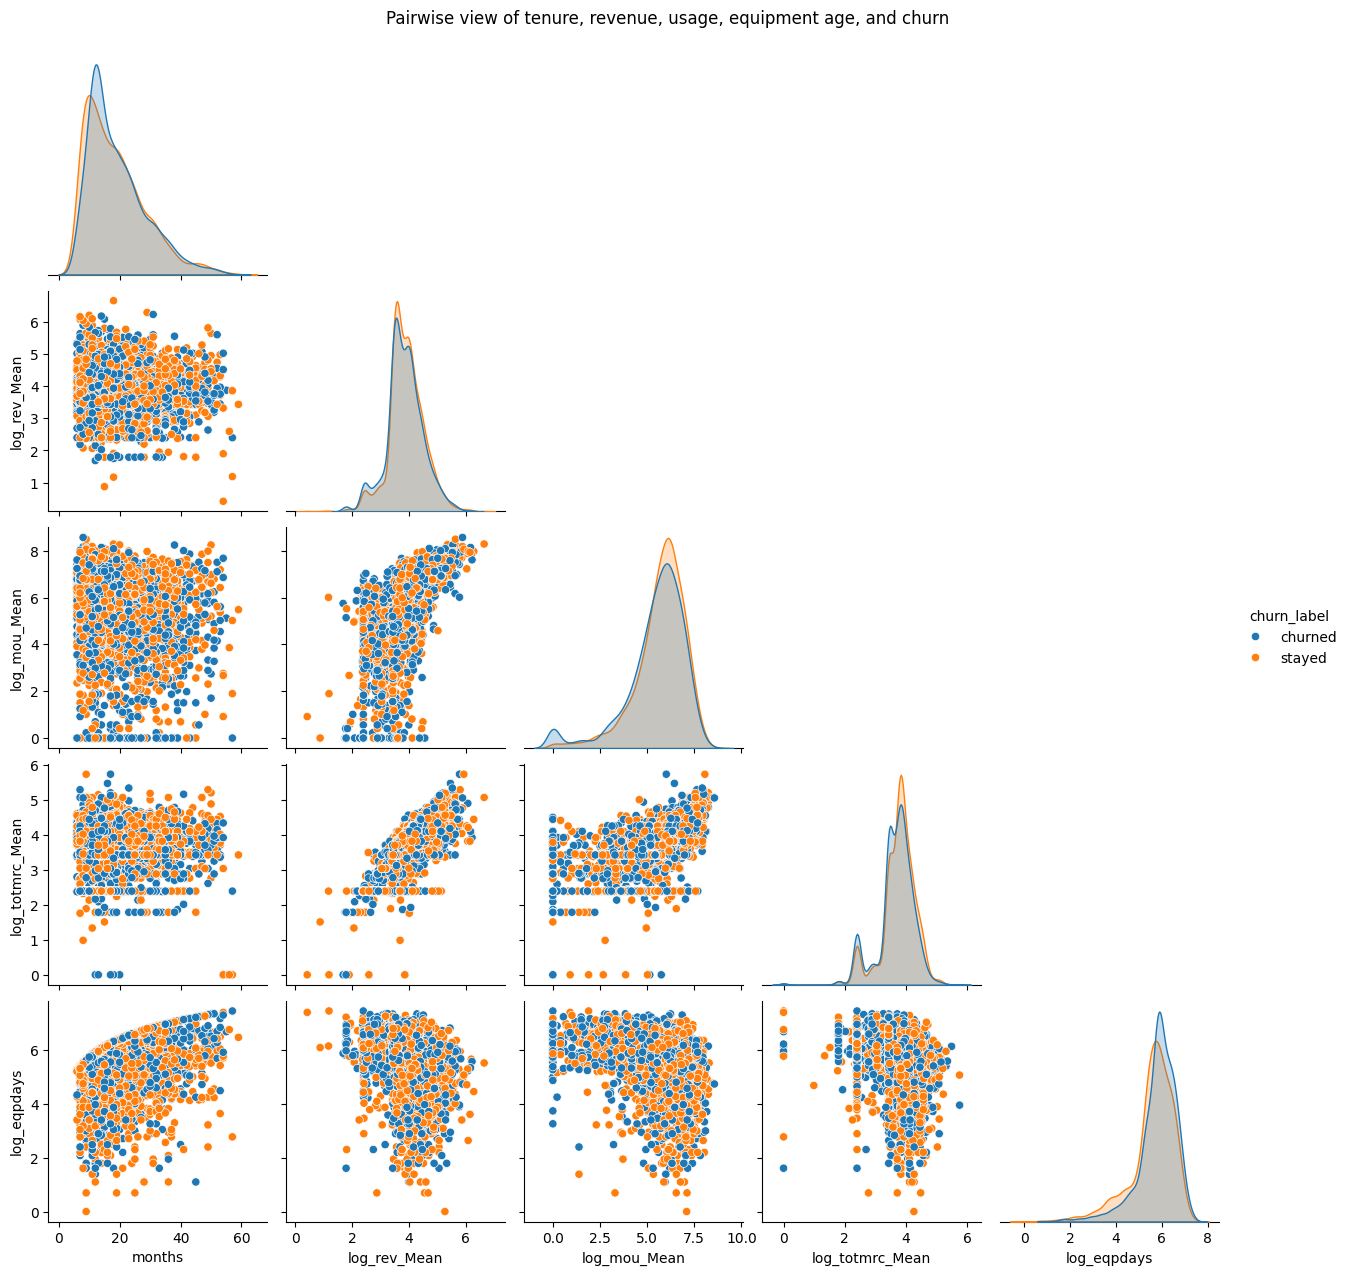

In [21]:
# Pairplot with log-transformed skewed variables
plot_df = df[[
    'months',
    'rev_Mean',
    'mou_Mean',
    'totmrc_Mean',
    'eqpdays',
    'churn'
]].dropna().copy()

# Log-transform highly skewed positive variables
plot_df['log_rev_Mean'] = np.log1p(plot_df['rev_Mean'])
plot_df['log_mou_Mean'] = np.log1p(plot_df['mou_Mean'])
plot_df['log_totmrc_Mean'] = np.log1p(plot_df['totmrc_Mean'])
plot_df['log_eqpdays'] = np.log1p(plot_df['eqpdays'])

plot_df['churn_label'] = plot_df['churn'].map({
    0: 'stayed',
    1: 'churned'
})

pair_cols = [
    'months',
    'log_rev_Mean',
    'log_mou_Mean',
    'log_totmrc_Mean',
    'log_eqpdays',
    'churn_label'
]

pair_sample = plot_df[pair_cols].sample(n=5000, random_state=42)

sns.pairplot(
    pair_sample,
    hue='churn_label',
    corner=True,
    diag_kind='kde',
)

plt.suptitle('Pairwise view of tenure, revenue, usage, equipment age, and churn', y=1.02)
plt.show()

The pairplot does not show a clean geometric separation between churners and non-churners.
This suggests that churn is not explained by a single simple numeric variable such as revenue or usage alone.
However, the diagonal distributions indicate that equipment age (`eqpdays`) is somewhat shifted for churned customers, making it a more interpretable candidate for business intervention.
Revenue- and usage-related variables appear correlated with each other, so they may act as overlapping proxies rather than independent explanations.


---

## 4.Problem Definition

The grading rubric scores your **business proposal**, not your model. The model is one input to the proposal — evidence that supports a specific recommendation. Before any preprocessing or modeling, write down — in a few sentences — what you are actually trying to solve, and what your proposal will ultimately recommend.

**Questions to think about:**

- Is `churn` really the right outcome for _your_ proposal? Could revenue, usage, equipment turnover, or something segment-specific be a better fit? Justify your choice from what you saw in EDA.
- What ML task does your target imply — classification, regression, clustering, anomaly detection? Each implies different metrics and a different kind of recommendation.
- How would you state your business question in one sentence a non-technical executive would understand?
- Who acts on the model's output, and what action do they take? A model whose output cannot be acted on is not a proposal.
- What concrete recommendation do you expect your proposal to make? The modeling work in the rest of the notebook should serve that recommendation.

The rest of this notebook proceeds with `churn` as a worked example — but every section is replaceable.


---

## 5.Preprocessing

EDA showed two things that need handling before we can train a model:

- Section 3.1 showed there are `object`-dtype columns. Most ML models can only learn from numbers, so these must be encoded.
- The data also includes `Customer_ID`, a unique identifier with no predictive value. Leaving it in lets the model "memorise" individuals and can destabilise feature importance.

The minimum we have to do is therefore: drop the ID, and convert each `object` column to integers. `LabelEncoder` maps each unique string to a distinct integer. It is the simplest possible encoder, and it makes two compromises worth knowing about:

- It imposes an arbitrary order on categories that have no natural one (e.g. `A=0, B=1, C=2` — the model sees `C` as "larger" than `A`).
- Casting to string first turns `NaN` into the literal string `"nan"`, so missing categorical values become just another category.


In [24]:
# Drop the ID column
df_clean = df.drop(columns=['Customer_ID'])

df.info()

# Find all columns that are stored as text (object dtype)
object_cols = df_clean.select_dtypes(include='object').columns.tolist()
print('Columns to encode:', object_cols)

# Encode each text column as integers
for col in object_cols:
    encoder = LabelEncoder()
    df_clean[col] = encoder.fit_transform(df_clean[col].astype(str))

print()
print('Shape after preprocessing:', df_clean.shape)
df_clean.head()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 100 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   rev_Mean          99643 non-null   float64
 1   mou_Mean          99643 non-null   float64
 2   totmrc_Mean       99643 non-null   float64
 3   da_Mean           99643 non-null   float64
 4   ovrmou_Mean       99643 non-null   float64
 5   ovrrev_Mean       99643 non-null   float64
 6   vceovr_Mean       99643 non-null   float64
 7   datovr_Mean       99643 non-null   float64
 8   roam_Mean         99643 non-null   float64
 9   change_mou        99109 non-null   float64
 10  change_rev        99109 non-null   float64
 11  drop_vce_Mean     100000 non-null  float64
 12  drop_dat_Mean     100000 non-null  float64
 13  blck_vce_Mean     100000 non-null  float64
 14  blck_dat_Mean     100000 non-null  float64
 15  unan_vce_Mean     100000 non-null  float64
 16  unan_dat_Mean     100000 non-nu

/tmp/ipykernel_217058/3754344121.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df_clean.select_dtypes(include='object').columns.tolist()


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,2,1,1,0,0,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,2,13,3,0,149.98999,2.0,2.0,2,0.0,0.0,0,15.0,1,3,1.0,0,4.0,3.0,2,0,0.0,9,0,0,0,0,0,1,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1,1,0,21,0,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,4,3,0,0,NaN,7.0,6.0,1,1.0,1.0,2,1.0,1,3,1.0,0,5.0,1.0,2,0,0.0,16,0,0,0,0,0,1,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1,1,2,7,0,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,2,6,0,0,29.98999,2.0,1.0,3,0.0,0.0,0,7.0,1,2,2.0,0,5.0,2.0,2,0,0.0,9,0,1,0,0,0,1,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1,1,2,4,0,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,3,3,0,0,29.98999,1.0,1.0,3,0.0,0.0,2,6.0,0,2,4.0,0,6.0,1.0,2,3,0.0,14,1,0,0,0,0,1,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1,1,2,0,0,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,4,10,3,0,149.98999,6.0,4.0,2,0.0,0.0,1,5.0,0,3,1.0,0,6.0,1.0,2,14,0.0,6,0,0,0,0,0,1,434.0


**Questions to think about:**

- How would you encode the categorical columns to preserve their information (e.g. keep `NaN` as its own category, or use a model that handles categoricals natively)?
- Beyond `Customer_ID`, are there columns you should drop — heavily missing (Section 3.2), near-duplicate, or likely to leak the target?
- What derived features — ratios, deltas, aggregates — could capture signal that no single raw column does (e.g. equipment-age relative to tenure, change in usage relative to baseline)?


---

## 6.Model Building (XGBoost)

The model is a tool the proposal uses, not the proposal itself. Its job is to give your recommendation an evidence base — _which signals matter, by how much, and for whom_. A great model with no actionable recommendation is not a passing submission. The goal of this section is not to maximise accuracy; it is to produce evidence the proposal can stand on.

A few choices in the code below are worth stating explicitly:

- **Why XGBoost.** The data is tabular with mixed numeric scales and label-encoded categoricals. XGBoost handles all of that without scaling, trains quickly on ~100K rows, gives feature importances we can use to explain the model, and has a simple sklearn-style API (`.fit()`, `.predict()`). It is one option among many — logistic regression (for interpretability), random forest, or LightGBM would also be reasonable.
- **Why a stratified train/test split.** We train on one slice and evaluate on a held-out slice the model hasn't seen. Stratifying by `churn` keeps both classes proportionally represented in both slices — useful at 50/50, essential if the target were imbalanced.
- **Why `random_state=42`.** Reproducibility — the grading rubric expects your notebook to give the same numbers when rerun.


In [ ]:
# Features (X) and target (y)
X = df_clean.drop('churn', axis=1)
y = df_clean['churn']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Define the model
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='logloss',
    random_state=42,
)

# Train
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

---

## 7.Evaluation

We need one number that says "is the model picking up real signal?" The simplest choice for binary classification is **accuracy** — the fraction of test-set predictions that match the true label. It is meaningful _here_ because Section 3.3 showed the classes are balanced; with 5% churn it would be misleading (a model that always predicts "stay" would score 0.95).

A single accuracy number doesn't tell you _where_ the model goes wrong. The **confusion matrix** breaks the test set into four cells — correctly-kept stayers, correctly-flagged churners, missed churners, and false alarms — and the business consequence of each error type is different.


Accuracy: 0.6368


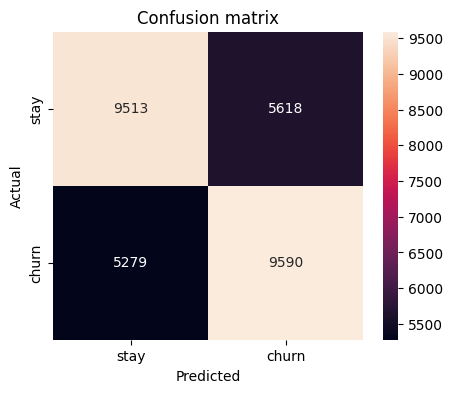

In [ ]:
# Accuracy on the held-out test set
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

# Confusion matrix: rows = actual class, columns = predicted class
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['stay', 'churn'],
            yticklabels=['stay', 'churn'])
plt.title('Confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Questions to think about:**

- A baseline that always predicts the majority class would score around 0.5 here. Does your accuracy meaningfully beat that? If not, the model isn't adding evidence yet.
- Accuracy treats false positives and false negatives equally. Are they really equally costly for _your_ proposal — flagging a stayer as a churner (wasted retention spend) versus missing a real churner (lost revenue)?
- What other metrics could you compute — AUC, precision, recall, F1? When would each be more informative than accuracy?
- If your accuracy looks suspiciously high, could a feature be leaking the target?


### 7.1 Feature importance

XGBoost reports several importance measures. Two simple ones: `weight` (how often a feature is used in any tree) and `gain` (how much it improves the model when used). For "which signals matter", `gain` is the more meaningful — a feature can be used often but contribute little, or rarely but decisively.


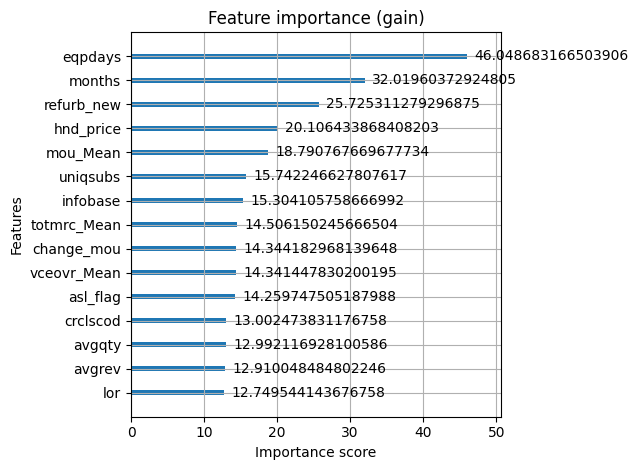

In [ ]:
plot_importance(model, max_num_features=15, importance_type='gain')
plt.title('Feature importance (gain)')
plt.tight_layout()
plt.show()

**Questions to think about:**

- Pick the top 3–5 features. For each, can the business actually _change_ it? Equipment age or customer-care call volume can be acted on; tenure and demographics cannot. Importance + intervenability is what produces a lever your proposal can pull.
- _Why_ might each feature plausibly drive your target? Importance tells you the model uses a feature, not why — and a story a CFO can probe is what your proposal will be judged on.
- If you removed the top feature and retrained, does the next-most-important feature tell the same story, or does the ranking reshuffle? That tells you whether you have one robust signal or several correlated proxies for the same underlying driver.


---

## 8.From Model to Proposal

The model gives a probability for each customer. By itself, that is not a proposal — it is one piece of evidence. The **proposal** is the recommendation: who to target, with what action, at what cost, for what expected return. Closing the gap is the assignment, and it is what separates a passing submission from a strong one.

A common failure mode is to present the model itself as the proposal ("we built a churn model with X% accuracy"). That is a technical report. The grading rubric wants a recommendation the model supports.

**Questions to think about:**

- Concretely, what does the business _do_ with a customer flagged as high risk — a retention offer? A service call? A plan change? The answer determines what counts as a successful intervention.
- If you ranked customers by predicted score and targeted the top 10% (or 20%, or some other cutoff), what fraction of actual churners would you catch? What is the right cutoff given the cost of action versus inaction?
- What is the average revenue per customer, the cost of an intervention, and the probability that the intervention actually works? Without these numbers — sourced or assumed transparently — you cannot put a dollar figure on the recommendation.
- Multiplying through (customers targeted × success rate × value retained, minus campaign cost), what is the expected impact? This is what the grading rubric means by _quantified business impact_. Show your assumptions.
- What happens if the model is wrong? What does the proposal not capture — substitution, cannibalisation, seasonality?
- How will you visualize your findings in the slides? The charts in this notebook are intentionally minimal — just enough to make a point. Your proposal slides should use polished, well-labelled visualizations that each communicate one clear takeaway. A messy chart loses your audience faster than no chart at all, and "use multiple data visualizations" is an explicit grading criterion.

A proposal that ends at _"the model predicts churn well"_ is incomplete. A proposal that ends at _"targeting the top 10% of customers by predicted score yields ~$X in retained revenue under these assumptions"_ is a proposal.


---

## 9.Conclusion

This is the end of the tutorial. Two things to carry forward:

- **The assignment is a business proposal backed by data, not a data analysis dressed up as a proposal.** Use the model to support a clear recommendation, with quantified impact and stated assumptions.
- **Originality counts.** A proposal that segments customers in an unusual way, reframes the problem, or grounds itself in a market you know well will stand out.

Good luck.

---

### Notes

- XGBoost in Colab: if you hit `ModuleNotFoundError`, run `!pip install xgboost` in a cell once and restart the runtime.
